In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

# Carregar shapefile
shp_path = '/home/valentim/divea/data/gis/Pr_Municipios_2024/PR_Municipios_2024.shp'
gdf = gpd.read_file(shp_path)

print(f"Shape: {gdf.shape}")
print(f"CRS: {gdf.crs}")
print(gdf.columns.tolist())
print(gdf.head(3))

Shape: (399, 16)
CRS: EPSG:4674
['CD_MUN', 'NM_MUN', 'CD_RGI', 'NM_RGI', 'CD_RGINT', 'NM_RGINT', 'CD_UF', 'NM_UF', 'SIGLA_UF', 'CD_REGIA', 'NM_REGIA', 'SIGLA_RG', 'CD_CONCU', 'NM_CONCU', 'AREA_KM2', 'geometry']
    CD_MUN           NM_MUN  CD_RGI                 NM_RGI CD_RGINT  NM_RGINT  \
0  4116703      Nova Aurora  410006               Cascavel     4103  Cascavel   
1  4106704  Cruzeiro do Sul  410019  Paranacity - Colorado     4104   Maringá   
2  4118501      Pato Branco  410010            Pato Branco     4103  Cascavel   

  CD_UF   NM_UF SIGLA_UF CD_REGIA NM_REGIA SIGLA_RG CD_CONCU NM_CONCU  \
0    41  Paraná       PR        4      Sul        S     None     None   
1    41  Paraná       PR        4      Sul        S     None     None   
2    41  Paraná       PR        4      Sul        S     None     None   

   AREA_KM2                                           geometry  
0   470.642  POLYGON ((-53.22871 -24.57286, -53.22878 -24.5...  
1   259.103  POLYGON ((-52.16211 -22.9541

In [2]:
# Carregar dados do SIVEP Paraná
df_pr = pd.read_parquet('/home/valentim/divea/data/processed/sivep_parana.parquet')

# Verificar formato dos códigos
print("SIVEP CO_MUN_RES:", df_pr['CO_MUN_RES'].head(5).tolist())
print("Shapefile CD_MUN:", gdf['CD_MUN'].head(5).tolist())

# Criar código de 6 dígitos no shapefile
gdf['CD_MUN6'] = gdf['CD_MUN'].str[:6]

print("\nApós conversão CD_MUN6:", gdf['CD_MUN6'].head(5).tolist())

SIVEP CO_MUN_RES: ['410830', '410830', '410430', '410830', '410830']
Shapefile CD_MUN: ['4116703', '4106704', '4118501', '4121109', '4108502']

Após conversão CD_MUN6: ['411670', '410670', '411850', '412110', '410850']


In [3]:
# Agregar casos por município e ano
df_mun = (
    df_pr.groupby(['CO_MUN_RES', 'ANO_ARQUIVO'])
    .size()
    .reset_index(name='casos')
)

print(f"Municípios únicos: {df_mun['CO_MUN_RES'].nunique()}")
print(df_mun.head(10))

Municípios únicos: 399
  CO_MUN_RES ANO_ARQUIVO  casos
0     410010        2020     14
1     410010        2021     54
2     410010        2022     12
3     410010        2023      8
4     410010        2024      5
5     410010        2025     12
6     410010        2026      1
7     410020        2019      1
8     410020        2020     36
9     410020        2021     62


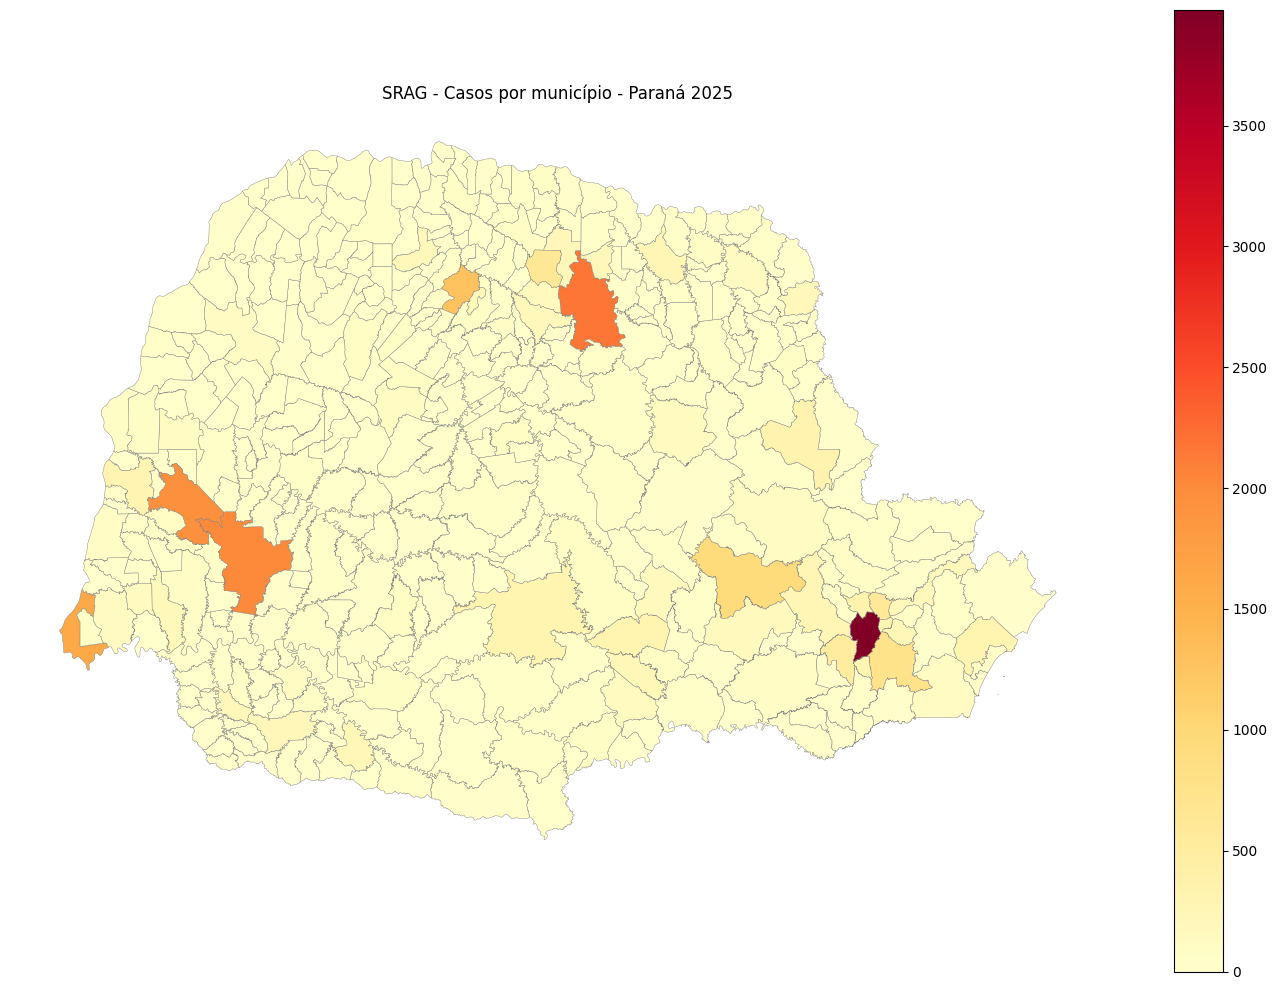

In [4]:
# Juntar com shapefile
gdf_casos = gdf.merge(
    df_mun[df_mun['ANO_ARQUIVO'] == '2025'],
    left_on='CD_MUN6',
    right_on='CO_MUN_RES',
    how='left'
).fillna(0)

# Mapa de casos 2025
fig, ax = plt.subplots(figsize=(14, 10))
gdf_casos.plot(
    column='casos',
    cmap='YlOrRd',
    legend=True,
    ax=ax,
    edgecolor='grey',
    linewidth=0.3
)
ax.set_title('SRAG - Casos por município - Paraná 2025')
ax.axis('off')
plt.tight_layout()
plt.savefig('/home/valentim/divea/outputs/mapa_casos_2025.png', dpi=150)
plt.show()

In [3]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from libpysal import weights
from esda import Moran, Moran_Local

# Carregar shapefile
shp_path = '/home/valentim/divea/data/gis/Pr_Municipios_2024/PR_Municipios_2024.shp'
gdf = gpd.read_file(shp_path)
gdf['CD_MUN6'] = gdf['CD_MUN'].str[:6]

# Carregar dados SIVEP
df_pr = pd.read_parquet('/home/valentim/divea/data/processed/sivep_parana.parquet')

# Agregar por município e ano
df_mun = (
    df_pr.groupby(['CO_MUN_RES', 'ANO_ARQUIVO'])
    .size()
    .reset_index(name='casos')
)

# Selecionar 2025
ano = '2025'
gdf_ano = gdf.merge(
    df_mun[df_mun['ANO_ARQUIVO'] == ano],
    left_on='CD_MUN6',
    right_on='CO_MUN_RES',
    how='left'
).fillna(0)

# Matriz de pesos espaciais
w = weights.Queen.from_dataframe(gdf_ano)
w.transform = 'r'

# Moran Global
y = gdf_ano['casos'].values
moran = Moran(y, w)
print(f"Índice de Moran Global: {moran.I:.4f}")
print(f"p-valor: {moran.p_sim:.4f}")

/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_20627/1595147622.py:33: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = weights.Queen.from_dataframe(gdf_ano)


Índice de Moran Global: 0.1165
p-valor: 0.0050


In [5]:
# Moran Local (LISA)
lisa = Moran_Local(y, w)

# Adicionar resultados ao geodataframe
gdf_ano['lisa_q'] = lisa.q          # quadrante (1=HH, 2=LH, 3=LL, 4=HL)
gdf_ano['lisa_p'] = lisa.p_sim      # p-valor simulado
gdf_ano['lisa_sig'] = lisa.p_sim < 0.05  # significativo?

# Classificar clusters
def classifica_cluster(row):
    if not row['lisa_sig']:
        return 'Não significativo'
    if row['lisa_q'] == 1:
        return 'HH - Alto-Alto'
    elif row['lisa_q'] == 2:
        return 'LH - Baixo-Alto'
    elif row['lisa_q'] == 3:
        return 'LL - Baixo-Baixo'
    elif row['lisa_q'] == 4:
        return 'HL - Alto-Baixo'

gdf_ano['cluster'] = gdf_ano.apply(classifica_cluster, axis=1)

print(gdf_ano['cluster'].value_counts())

cluster
Não significativo    332
LL - Baixo-Baixo      34
LH - Baixo-Alto       16
HH - Alto-Alto        14
HL - Alto-Baixo        3
Name: count, dtype: int64


/tmp/ipykernel_20627/274069359.py:17: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower right', fontsize=9)
/tmp/ipykernel_20627/274069359.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right', fontsize=9)


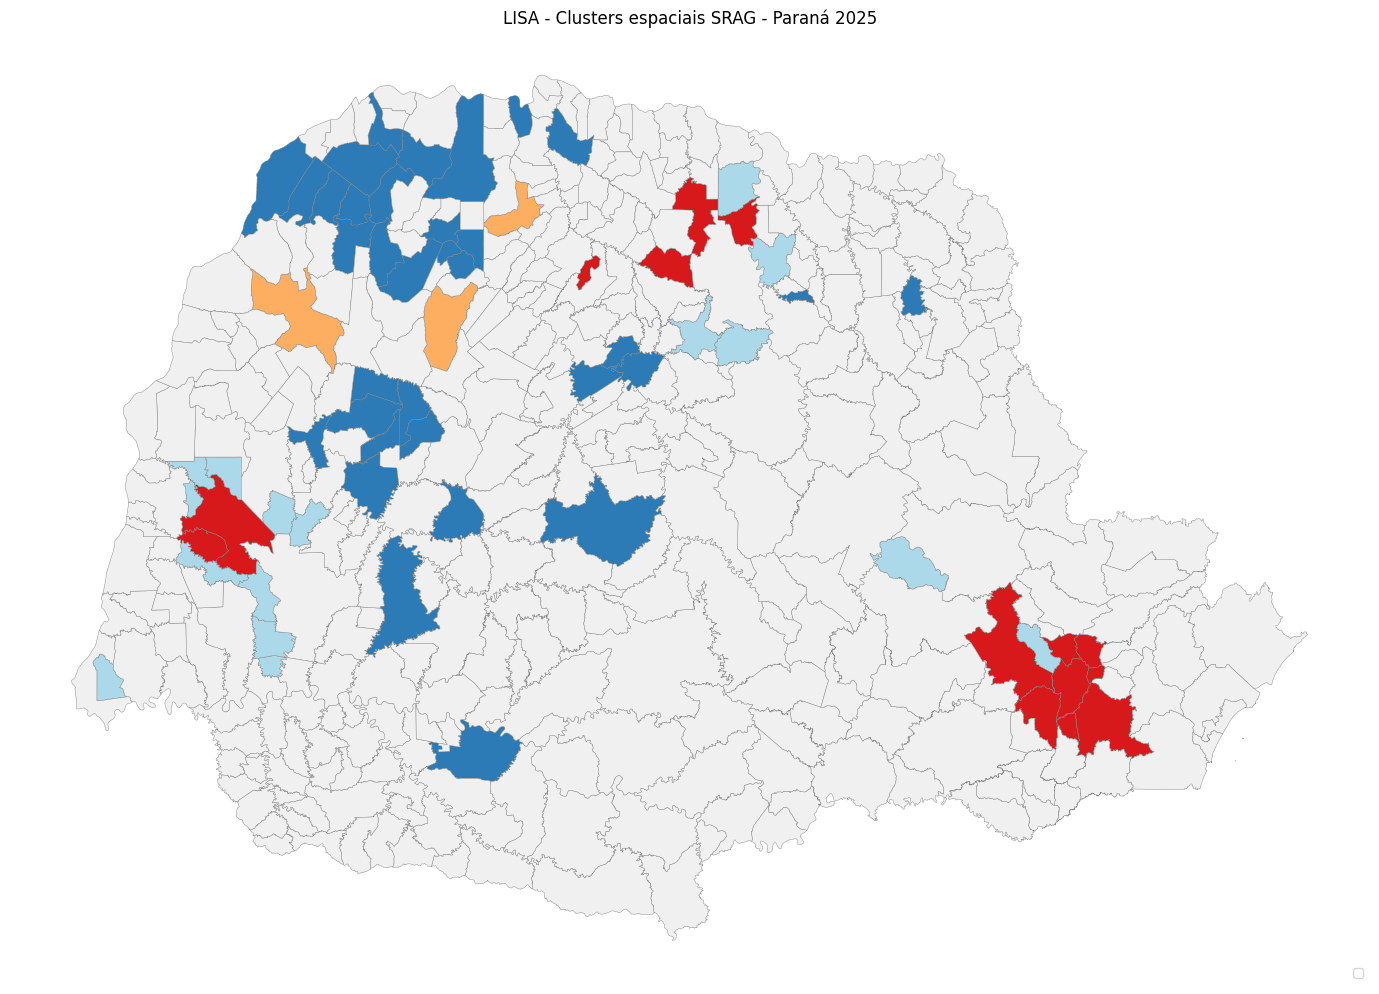

In [6]:
cores = {
    'HH - Alto-Alto': '#d7191c',
    'HL - Alto-Baixo': '#fdae61',
    'LH - Baixo-Alto': '#abd9e9',
    'LL - Baixo-Baixo': '#2c7bb6',
    'Não significativo': '#f0f0f0'
}

gdf_ano['cor'] = gdf_ano['cluster'].map(cores)

fig, ax = plt.subplots(figsize=(14, 10))
for cluster, cor in cores.items():
    gdf_ano[gdf_ano['cluster'] == cluster].plot(
        ax=ax, color=cor, edgecolor='grey', linewidth=0.3, label=cluster
    )

ax.legend(loc='lower right', fontsize=9)
ax.set_title(f'LISA - Clusters espaciais SRAG - Paraná {ano}')
ax.axis('off')
plt.tight_layout()
plt.savefig(f'/home/valentim/divea/outputs/lisa_srag_{ano}.png', dpi=150)
plt.show()

In [7]:
hh = gdf_ano[gdf_ano['cluster'] == 'HH - Alto-Alto'][['NM_MUN', 'casos', 'cluster']]
hh = hh.sort_values('casos', ascending=False)
print(hh.to_string(index=False))

              NM_MUN  casos        cluster
            Curitiba 3978.0 HH - Alto-Alto
              Toledo 1948.0 HH - Alto-Alto
São José dos Pinhais  754.0 HH - Alto-Alto
             Colombo  601.0 HH - Alto-Alto
           Araucária  528.0 HH - Alto-Alto
 Almirante Tamandaré  348.0 HH - Alto-Alto
  Fazenda Rio Grande  293.0 HH - Alto-Alto
             Pinhais  286.0 HH - Alto-Alto
         Campo Largo  278.0 HH - Alto-Alto
               Cambé  225.0 HH - Alto-Alto
             Ibiporã  214.0 HH - Alto-Alto
             Sarandi  188.0 HH - Alto-Alto
           Arapongas  160.0 HH - Alto-Alto
 Ouro Verde do Oeste   97.0 HH - Alto-Alto


In [8]:
# Salvar resultados LISA
gdf_ano[['CD_MUN', 'NM_MUN', 'casos', 'cluster', 'lisa_q', 'lisa_p']].to_csv(
    f'/home/valentim/divea/outputs/lisa_municipios_{ano}.csv', index=False
)
print("Salvo.")

Salvo.
